### SML-OA ALGORITHM SIMULATION

In [17]:
import pandas as pd
import numpy as np

# 1. HARDCODE THE EXACT INPUTS FROM MANUSCRIPT TABLE 1
df_new_tasks = pd.DataFrame({
    "Task_ID": np.arange(1, 16),
    "Task_Size_GB": [17.0252, 0.8913, 1.5339, 3.0483, 21.6837, 7.7460, 1.5378, 3.3846, 2.3504, 2.0961, 15.9590, 0.9477, 33.8485, 13.2670, 18.1817],
    "CPU_Demand_Units": [17.0605, 36.6970, 22.2945, 19.1720, 41.9427, 9.0773, 54.4410, 13.9925, 6.6397, 15.0989, 30.4829, 9.5654, 14.4299, 27.3183, 12.4009],
    "Predicted_Exec_Time_ms": [10.4598, 24.0098, 11.6967, 10.7894, 15.4186, 7.8465, 21.3972, 9.4363, 6.2965, 8.9807, 12.4455, 7.8444, 19.2160, 12.4419, 9.0768]
})

# 2. APPLY FIXED COS WEIGHTS FROM EQUATION 8
w_s = 0.4315
w_r = 0.4163
w_t = 0.1522

edge_capacity = 5
cloud_capacity = 10
edge_queue = []
cloud_queue = []
log_records = []
window_size = 5

# NORMALIZATION FUNCTION
def safe_min_max_normalize(series):
    s_min = series.min()
    s_max = series.max()
    if s_max == s_min:
        return pd.Series([0.5] * len(series), index=series.index)
    return (series - s_min) / (s_max - s_min)

# 3. EXTRACT WINDOW 1 (TASKS 1-5)
window_size = 5
window_df = df_new_tasks.iloc[0:window_size].copy()

# 4. COMPUTE DYNAMIC NORMALIZATION
window_df["S_norm"] = safe_min_max_normalize(window_df["Task_Size_GB"])
window_df["R_norm"] = safe_min_max_normalize(window_df["CPU_Demand_Units"])
window_df["T_norm"] = safe_min_max_normalize(window_df["Predicted_Exec_Time_ms"])

# 5. COMPUTE COS AND ROUND TO 4 DECIMALS 
window_df["COS"] = (
    w_s * window_df["S_norm"] +
    w_r * window_df["R_norm"] +
    w_t * window_df["T_norm"]
)

# === REPLICATING TABLE V ===
table_5 = window_df[["Task_ID", "S_norm", "R_norm", "T_norm", "COS"]].copy()
table_5 = table_5.round(4)
print("--- TABLE V: Normalised features and COS values for Window 1 ---")
print(table_5.to_string(index=False))
print("\n" + "="*60 + "\n")

# 6. COMPUTE IQR THRESHOLDS USING N+1 INTERPOLATION (weibull method)
cos_values = window_df["COS"]
q1 = np.percentile(cos_values, 25, method='weibull')
q3 = np.percentile(cos_values, 75, method='weibull')

# 7. ASSIGN TIERS
tiers = []
for cos_val in cos_values:
    if cos_val < q1:
        tiers.append("IoT")
    elif cos_val > q3:
        tiers.append("Cloud")
    else:
        tiers.append("Edge")
        
window_df["Assigned Tier"] = tiers

# === REPLICATING TABLE VI ===
table_6 = window_df[["Task_ID", "COS", "Assigned Tier"]].copy()
table_6["COS"] = table_6["COS"].round(4)
print("--- TABLE VI: Tier decisions for Window 1 based on COS and IQR rules ---")
print(table_6.to_string(index=False))

--- TABLE V: Normalised features and COS values for Window 1 ---
 Task_ID  S_norm  R_norm  T_norm    COS
       1  0.7760  0.0000  0.0000 0.3348
       2  0.0000  0.7892  1.0000 0.4807
       3  0.0309  0.2104  0.0913 0.1148
       4  0.1037  0.0849  0.0243 0.0838
       5  1.0000  1.0000  0.3660 0.9035


--- TABLE VI: Tier decisions for Window 1 based on COS and IQR rules ---
 Task_ID    COS Assigned Tier
       1 0.3348          Edge
       2 0.4807          Edge
       3 0.1148          Edge
       4 0.0838           IoT
       5 0.9035         Cloud


In [18]:
# PROCESS TASKS USING TUMBLING WINDOW
for window_start in range(0, len(df_new_tasks), window_size):
    window_df = df_new_tasks.iloc[window_start:window_start + window_size].copy()
    window_id = (window_start // window_size) + 1

    window_df["S_norm"] = safe_min_max_normalize(window_df["Task_Size_GB"])
    window_df["R_norm"] = safe_min_max_normalize(window_df["CPU_Demand_Units"])
    window_df["T_norm"] = safe_min_max_normalize(window_df["Predicted_Exec_Time_ms"])

    window_df["COS"] = (
        w_s * window_df["S_norm"]
        + w_r * window_df["R_norm"]
        + w_t * window_df["T_norm"]
    )
    window_df["COS"] = window_df["COS"].round(4)

    cos_values = window_df["COS"]
    q1 = np.percentile(cos_values, 25, method='weibull')
    q3 = np.percentile(cos_values, 75, method='weibull')
    iqr = q3 - q1

    cos_skewness = skew(cos_values, bias=True)
    cos_kurtosis = kurtosis(cos_values, fisher=False, bias=True)

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    k_threshold = 3.5

    for idx, row in window_df.iterrows():
        task_id = int(row["Task_ID"])
        current_cos = float(row["COS"])

        is_outlier = (current_cos < lower_fence) or (current_cos > upper_fence)
        is_volatile = cos_kurtosis > k_threshold
        is_anomaly = is_outlier and is_volatile

        if current_cos < q1:
            stat_decision = "IoT"
        elif current_cos > q3:
            stat_decision = "Cloud"
        else:
            stat_decision = "Edge"

        stress_flag = False
        stress_action = None

        if is_anomaly:
            target_tier = "Cloud"
            anomaly_flag = True
        else:
            target_tier = stat_decision
            anomaly_flag = False

        if target_tier == "Edge" and len(edge_queue) >= edge_capacity:
            stress_flag = True
            stress_action = "EdgeFull_OffloadToCloud"
            target_tier = "Cloud"

        if target_tier == "Cloud" and len(cloud_queue) >= cloud_capacity:
            stress_flag = True
            stress_action = "EdgeCloudFull_StopOffloading"
            final_tier = "StopOffloading"
        else:
            final_tier = target_tier

        if final_tier == "Edge":
            edge_queue.append(task_id)
        elif final_tier == "Cloud":
            cloud_queue.append(task_id)

        log_records.append({
            "Task_ID": task_id,
            "Window_ID": window_id,
            "Task_Size_GB": row["Task_Size_GB"],
            "CPU_Demand_Units": row["CPU_Demand_Units"],
            "Predicted_Exec_Time_ms": row["Predicted_Exec_Time_ms"],
            "COS": current_cos,
            "Q1": round(q1, 4),
            "Q3": round(q3, 4),
            "IQR": round(iqr, 4),
            "Skewness": round(cos_skewness, 4),
            "Kurtosis": round(cos_kurtosis, 4),
            "Is_Outlier": is_outlier,
            "Is_Volatile": is_volatile,
            "Is_Anomaly": anomaly_flag,
            "Statistical_Tier": stat_decision,
            "Final_Tier": final_tier,
            "Stress_Flag": stress_flag,
            "Stress_Action": stress_action,
            "Edge_Queue_Length": len(edge_queue),
            "Cloud_Queue_Length": len(cloud_queue)
        })

df_log = pd.DataFrame(log_records)

In [19]:
df_log

,Task_ID,Window_ID,Task_Size_GB,CPU_Demand_Units,Predicted_Exec_Time_ms,COS,Q1,Q3,IQR,Skewness,Kurtosis,Is_Outlier,Is_Volatile,Is_Anomaly,Statistical_Tier,Final_Tier,Stress_Flag,Stress_Action,Edge_Queue_Length,Cloud_Queue_Length
0,1,1,17.0252,17.0605,10.4598,0.3348,0.0993,0.6921,0.5928,0.7179,2.1911,False,False,False,Edge,Edge,False,None,1,0
1,2,1,0.8913,36.6970,24.0098,0.4807,0.0993,0.6921,0.5928,0.7179,2.1911,False,False,False,Edge,Edge,False,None,2,0
2,3,1,1.5339,22.2945,11.6967,0.1148,0.0993,0.6921,0.5928,0.7179,2.1911,False,False,False,Edge,Edge,False,None,3,0
3,4,1,3.0483,19.1720,10.7894,0.0838,0.0993,0.6921,0.5928,0.7179,2.1911,False,False,False,IoT,IoT,False,None,3,0
4,5,1,21.6837,41.9427,15.4186,0.9035,0.0993,0.6921,0.5928,0.7179,2.1911,False,False,False,Cloud,Cloud,False,None,3,1
5,6,2,7.7460,9.0773,7.8465,0.4684,0.0980,0.5184,0.4204,0.2697,1.4372,False,False,False,Edge,Edge,False,None,4,1
6,7,2,1.5378,54.4410,21.3972,0.5685,0.0980,0.5184,0.4204,0.2697,1.4372,False,False,False,Cloud,Cloud,False,None,4,2
7,8,2,3.3846,13.9925,9.4363,0.2240,0.0980,0.5184,0.4204,0.2697,1.4372,False,False,False,Edge,Edge,False,None,5,2
8,9,2,2.3504,6.6397,6.2965,0.0565,0.0980,0.5184,0.4204,0.2697,1.4372,False,False,False,IoT,IoT,False,None,5,2
9,10,2,2.0961,15.0989,8.9807,0.1395,0.0980,0.5184,0.4204,0.2697,1.4372,False,False,False,Edge,Cloud,True,EdgeFull_OffloadToCloud,5,3


# OPERATOR DASHBOARD VISUALIZATIONS

### COS DISTRIBUTION

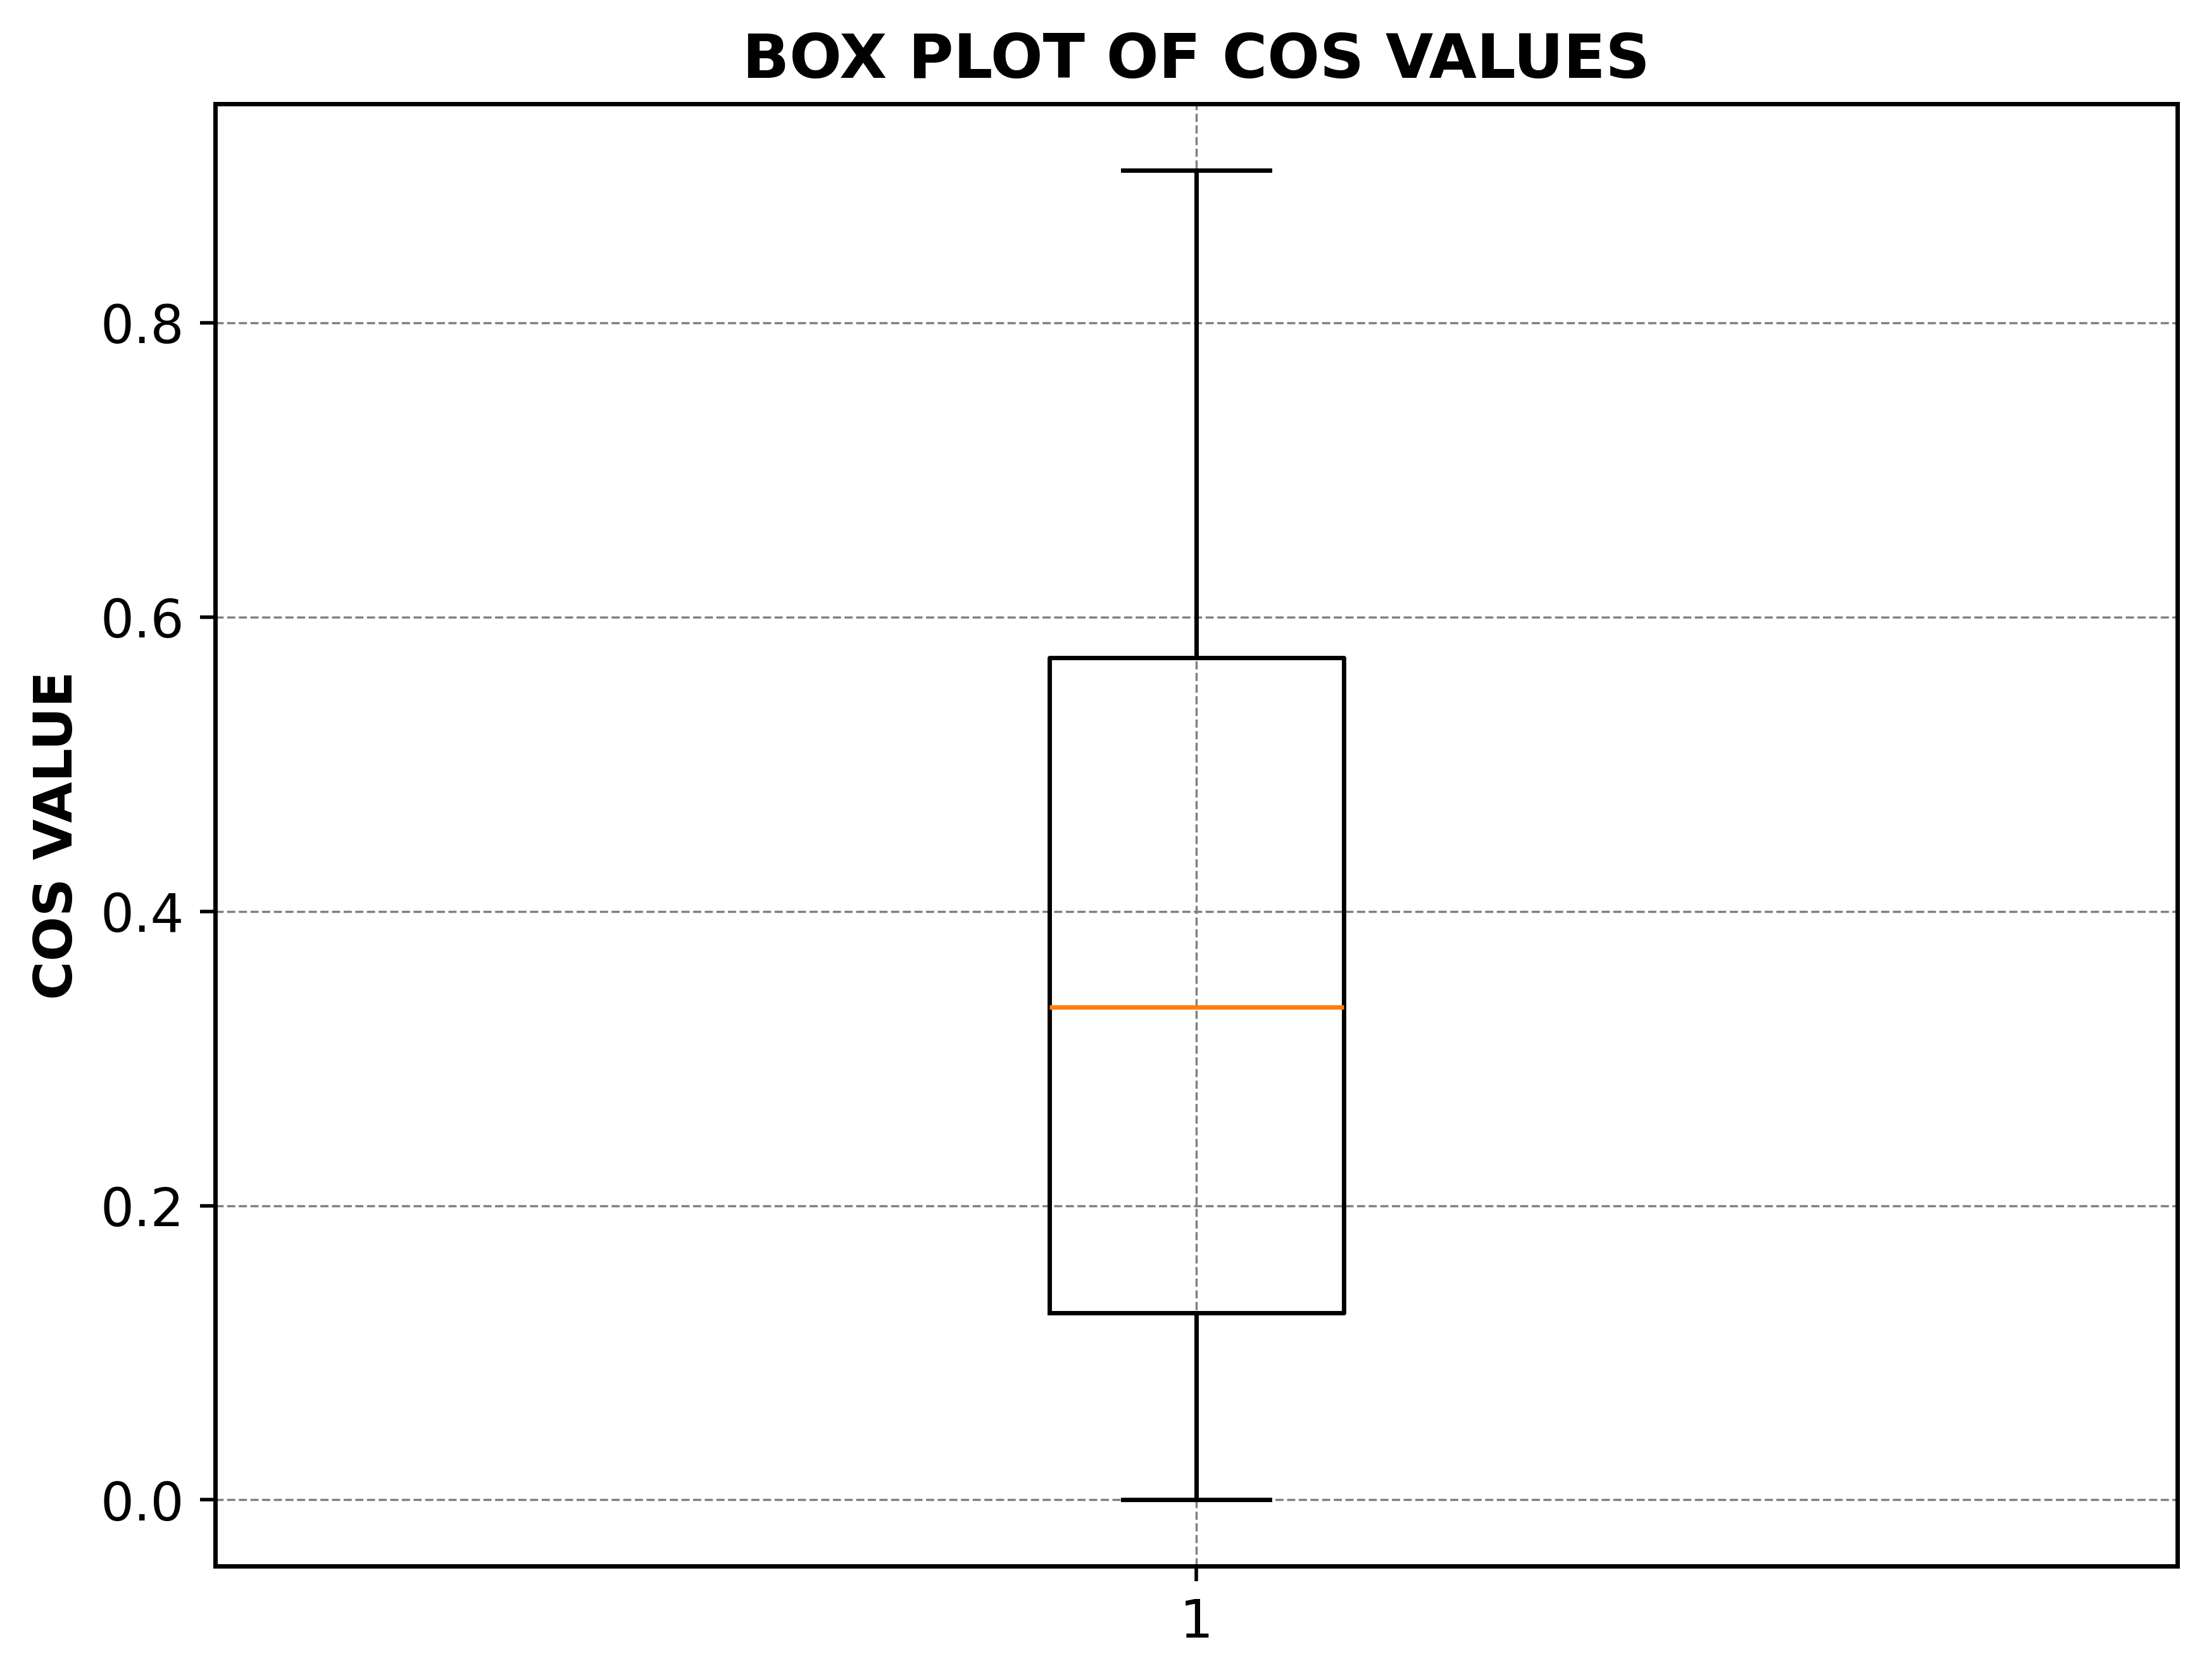

In [20]:
plt.figure(figsize=(8, 6), dpi=500)
plt.boxplot(df_log["COS"], vert=True)
plt.title("BOX PLOT OF COS VALUES", fontsize=14)
plt.ylabel("COS VALUE", fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

### COS TIERING SCATTER

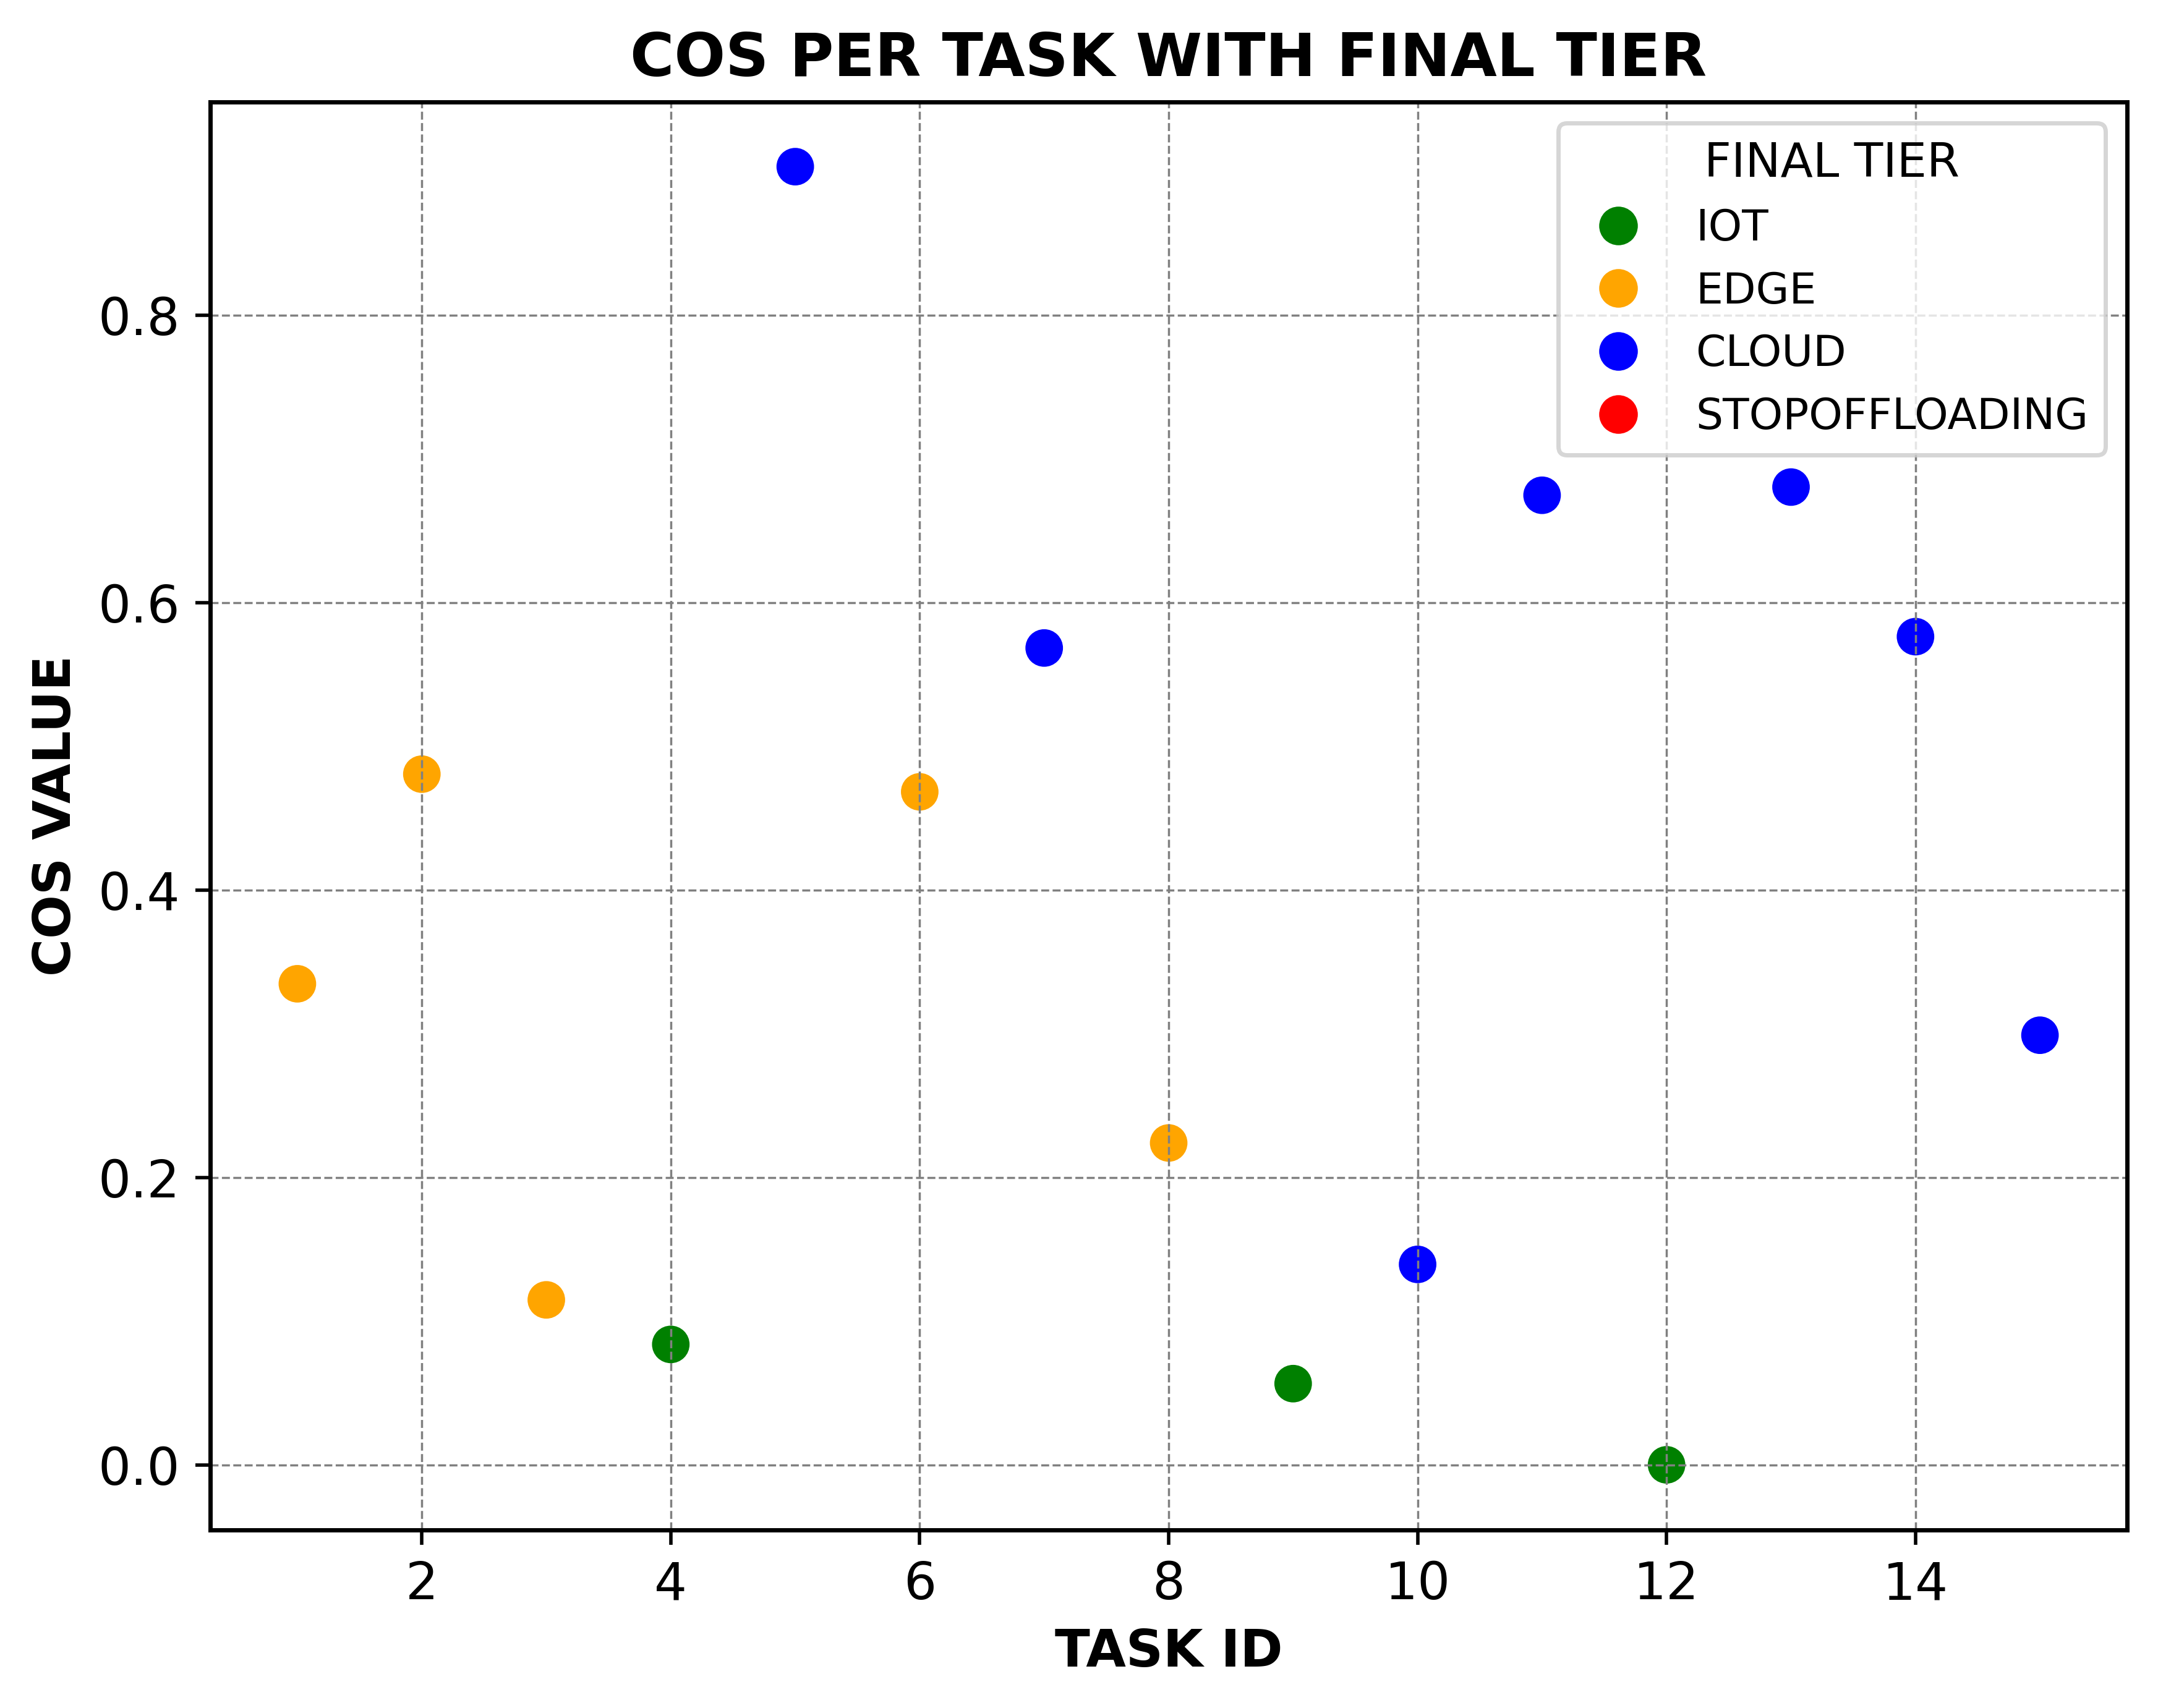

In [21]:
color_map = {
    "IoT": "green",
    "Edge": "orange",
    "Cloud": "blue",
    "StopOffloading": "red"
}
colors = df_log["Final_Tier"].map(color_map)

plt.figure(figsize=(8, 6), dpi=500)
plt.scatter(df_log["Task_ID"], df_log["COS"], c=colors, s=60)
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[key], markersize=10, label=key.upper())
    for key in color_map
]
plt.legend(handles=legend_handles, title="FINAL TIER", fontsize=10, title_fontsize=11)
plt.xlabel("TASK ID", fontsize=12)
plt.ylabel("COS VALUE", fontsize=12)
plt.title("COS PER TASK WITH FINAL TIER", fontsize=14)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

### SKEWNESS AND KURTOSIS TRENDS

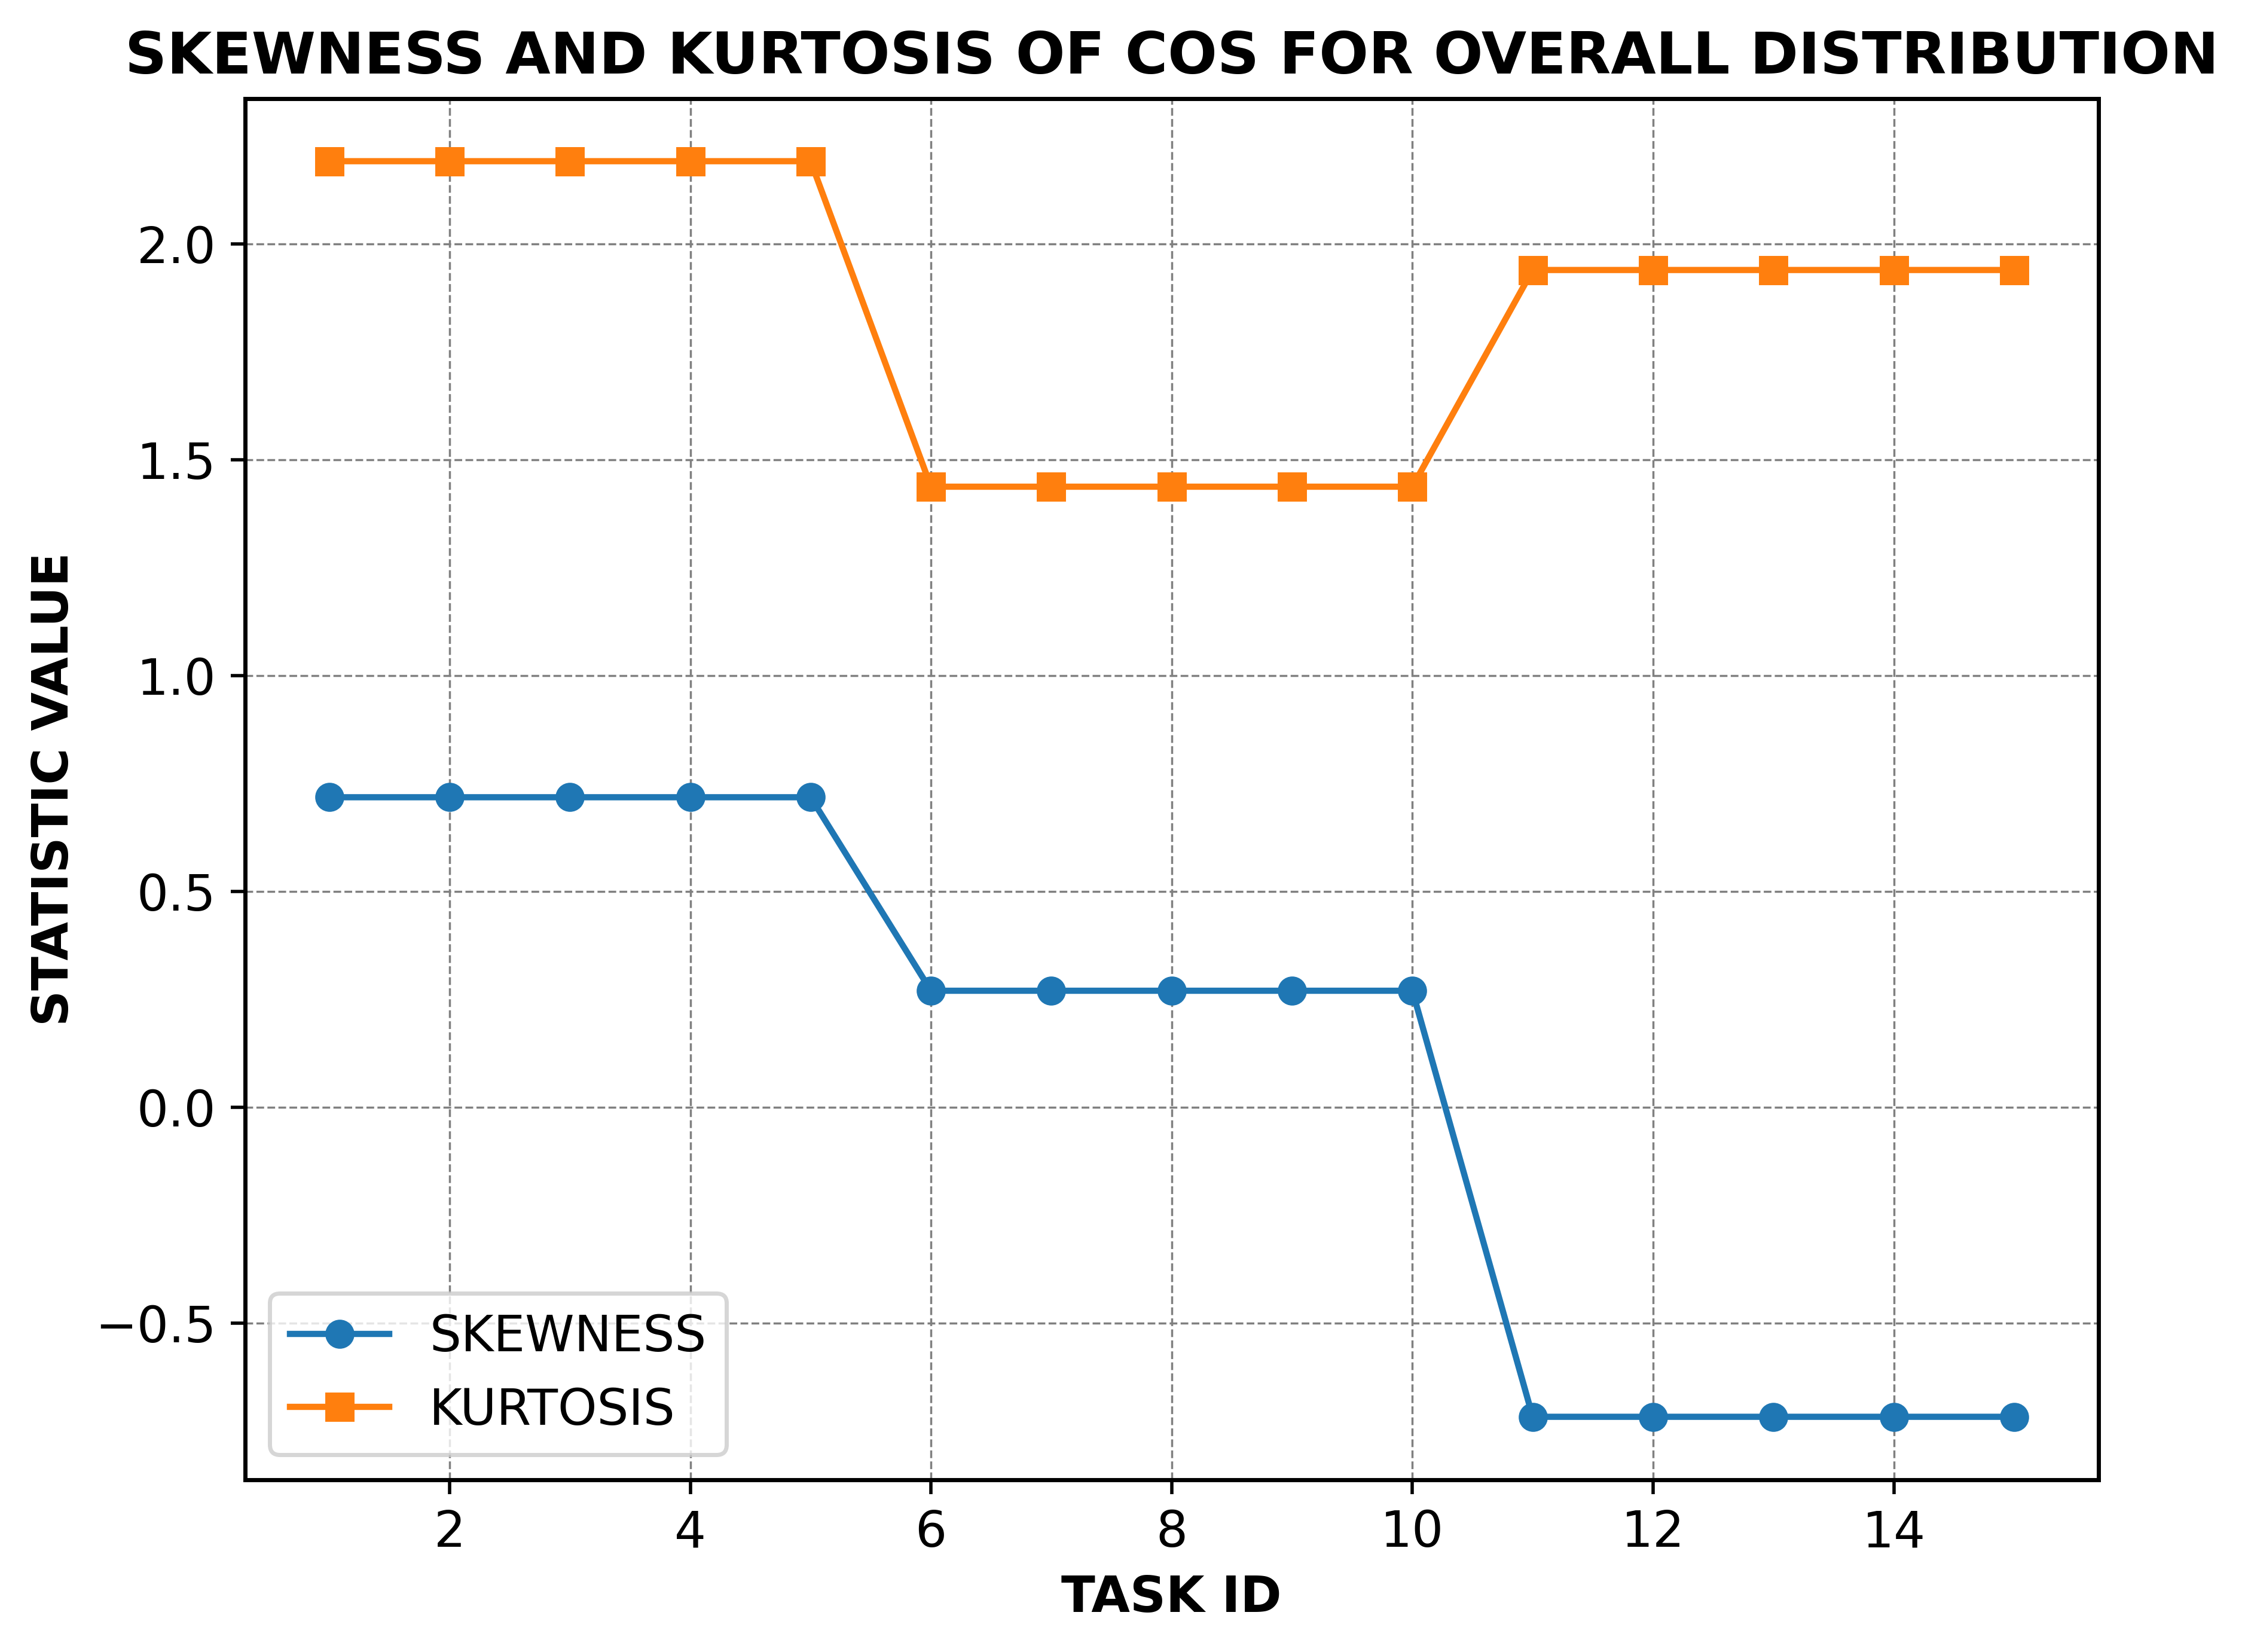

In [22]:
plt.figure(figsize=(8, 6), dpi=500)
plt.plot(df_log["Task_ID"], df_log["Skewness"], marker="o", label="SKEWNESS")
plt.plot(df_log["Task_ID"], df_log["Kurtosis"], marker="s", label="KURTOSIS")
plt.xlabel("TASK ID", fontsize=12)
plt.ylabel("STATISTIC VALUE", fontsize=12)
plt.title("SKEWNESS AND KURTOSIS OF COS FOR OVERALL DISTRIBUTION", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

### TIER-WISE TASK DISTRIBUTION

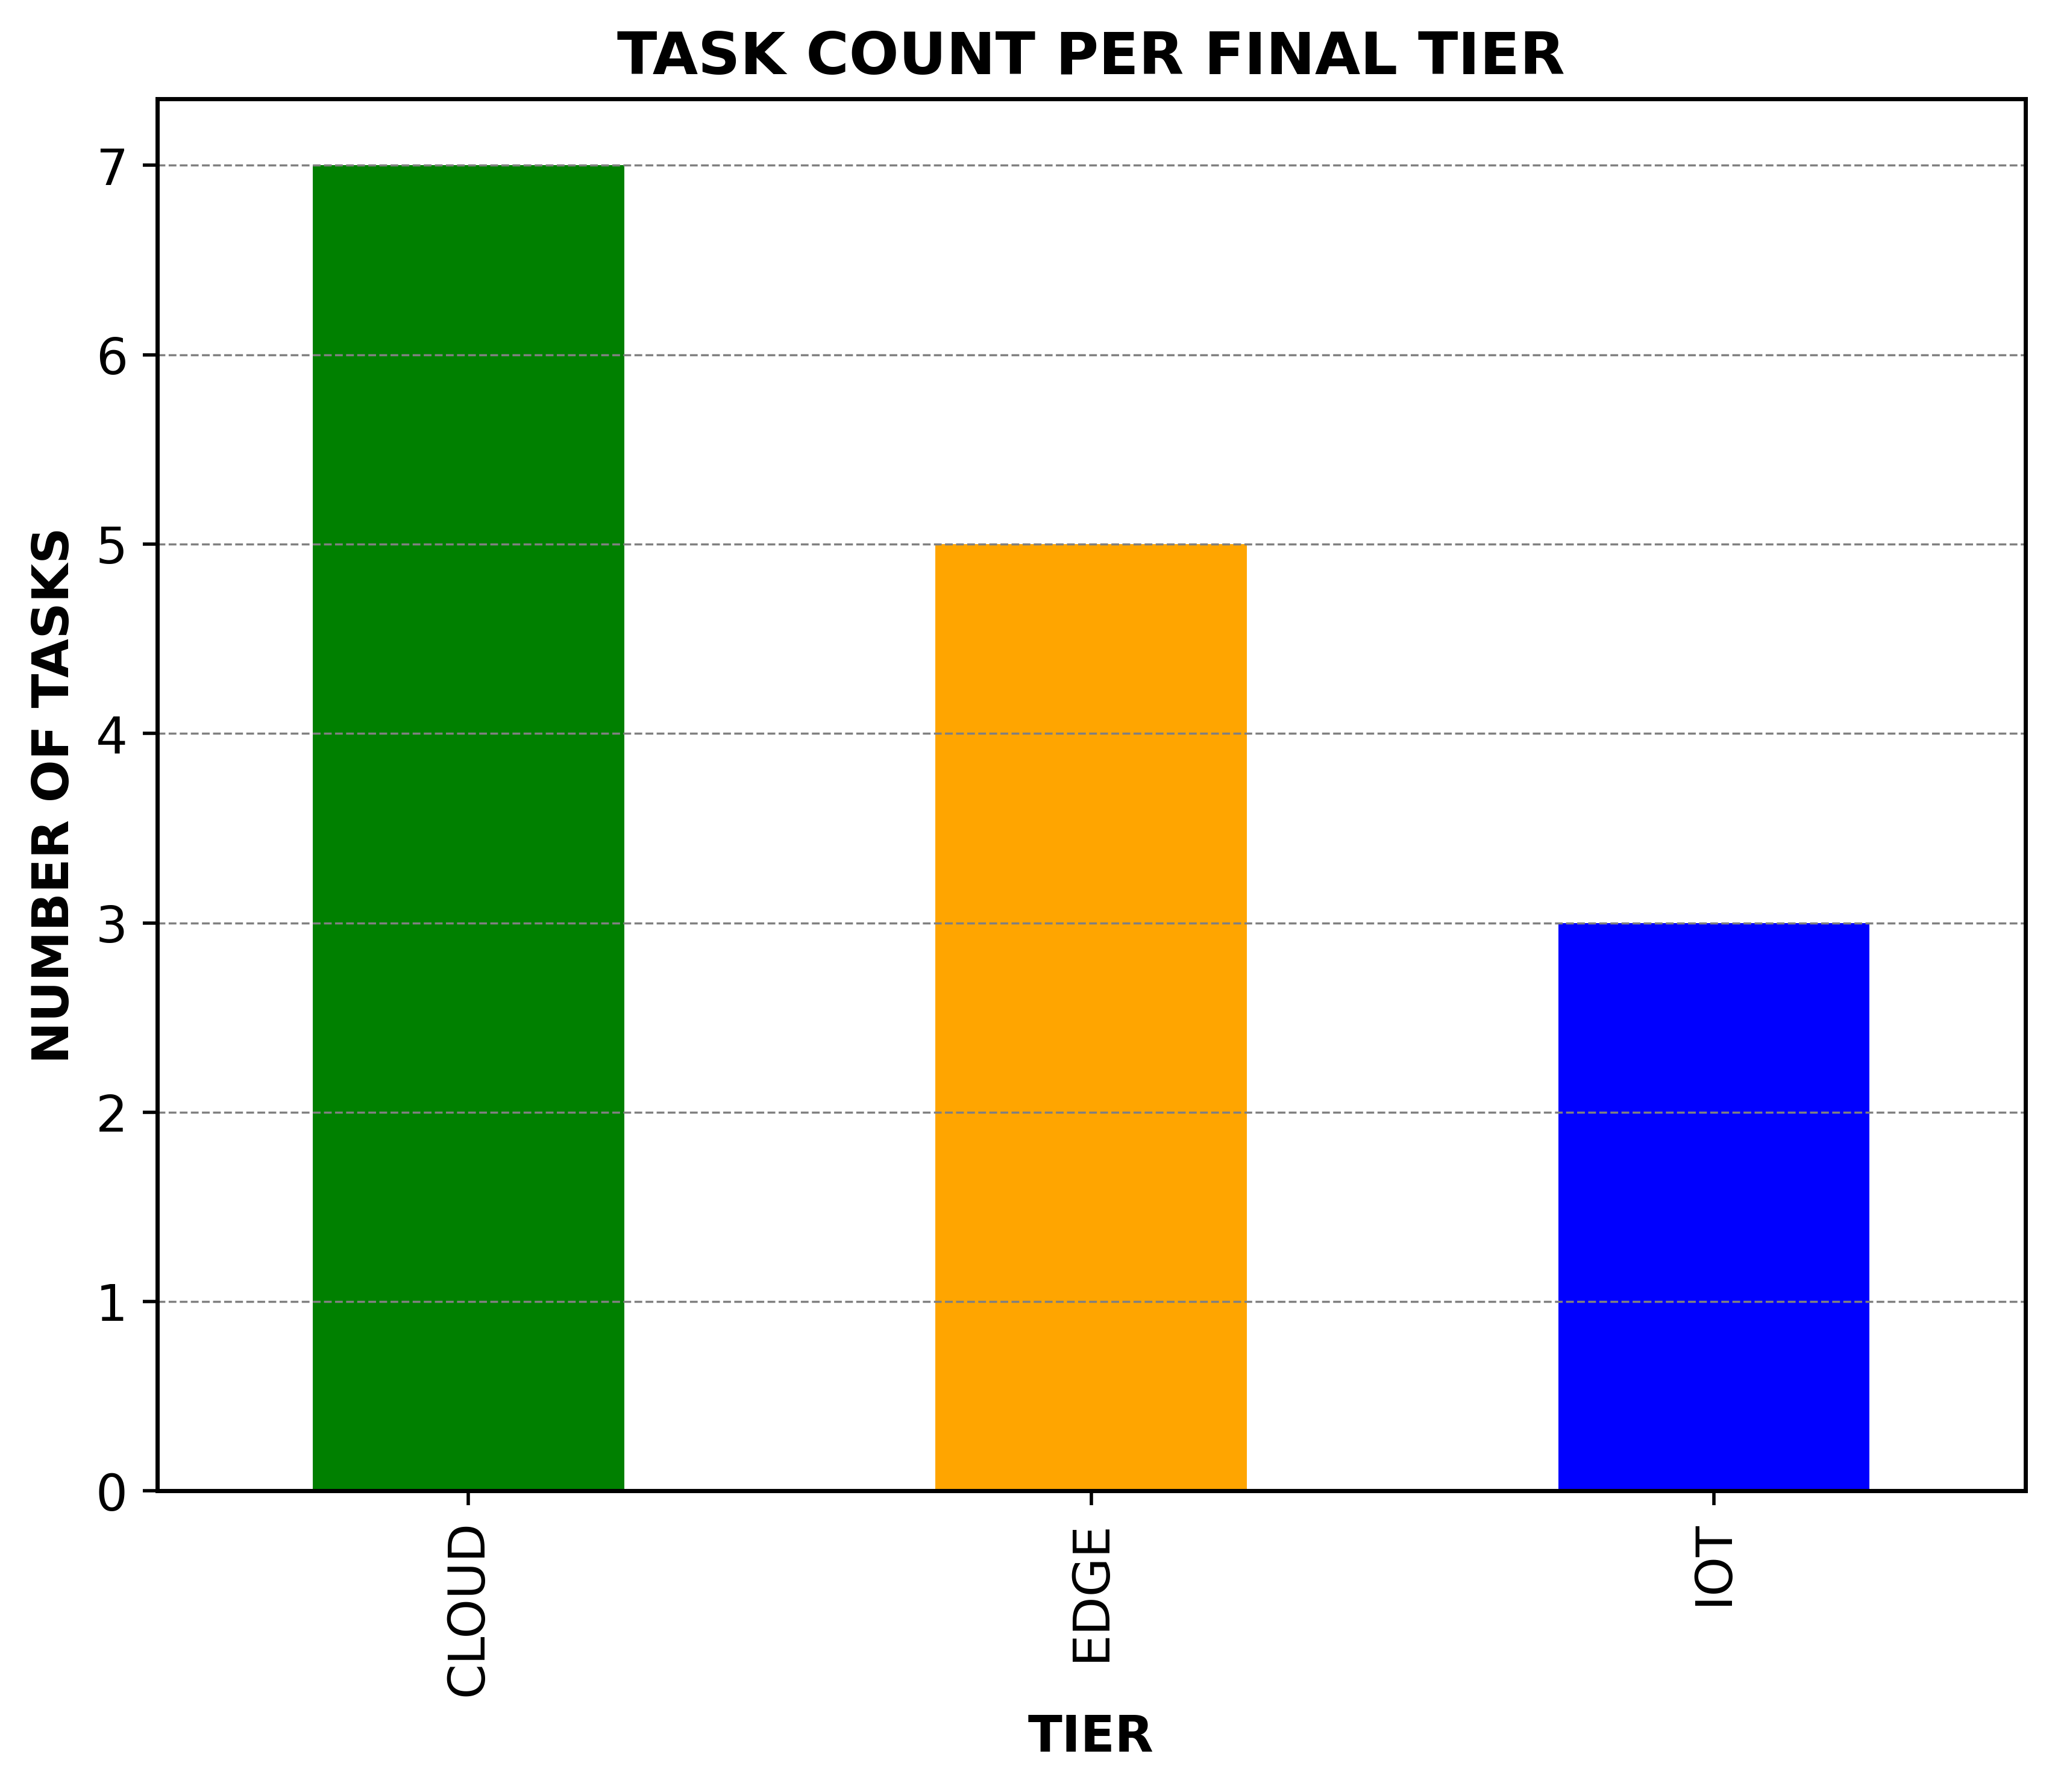

In [23]:
tier_counts = df_log["Final_Tier"].value_counts()
tier_counts.index = tier_counts.index.str.upper()  

plt.figure(figsize=(8, 6), dpi=500)
tier_counts.plot(kind="bar", color=["green", "orange", "blue", "red"])
plt.title("TASK COUNT PER FINAL TIER", fontsize=14)
plt.xlabel("TIER", fontsize=12)
plt.ylabel("NUMBER OF TASKS", fontsize=12)
plt.grid(axis="y", linestyle='--', linewidth=0.5)
plt.show()

### ANOMALY DETECTION

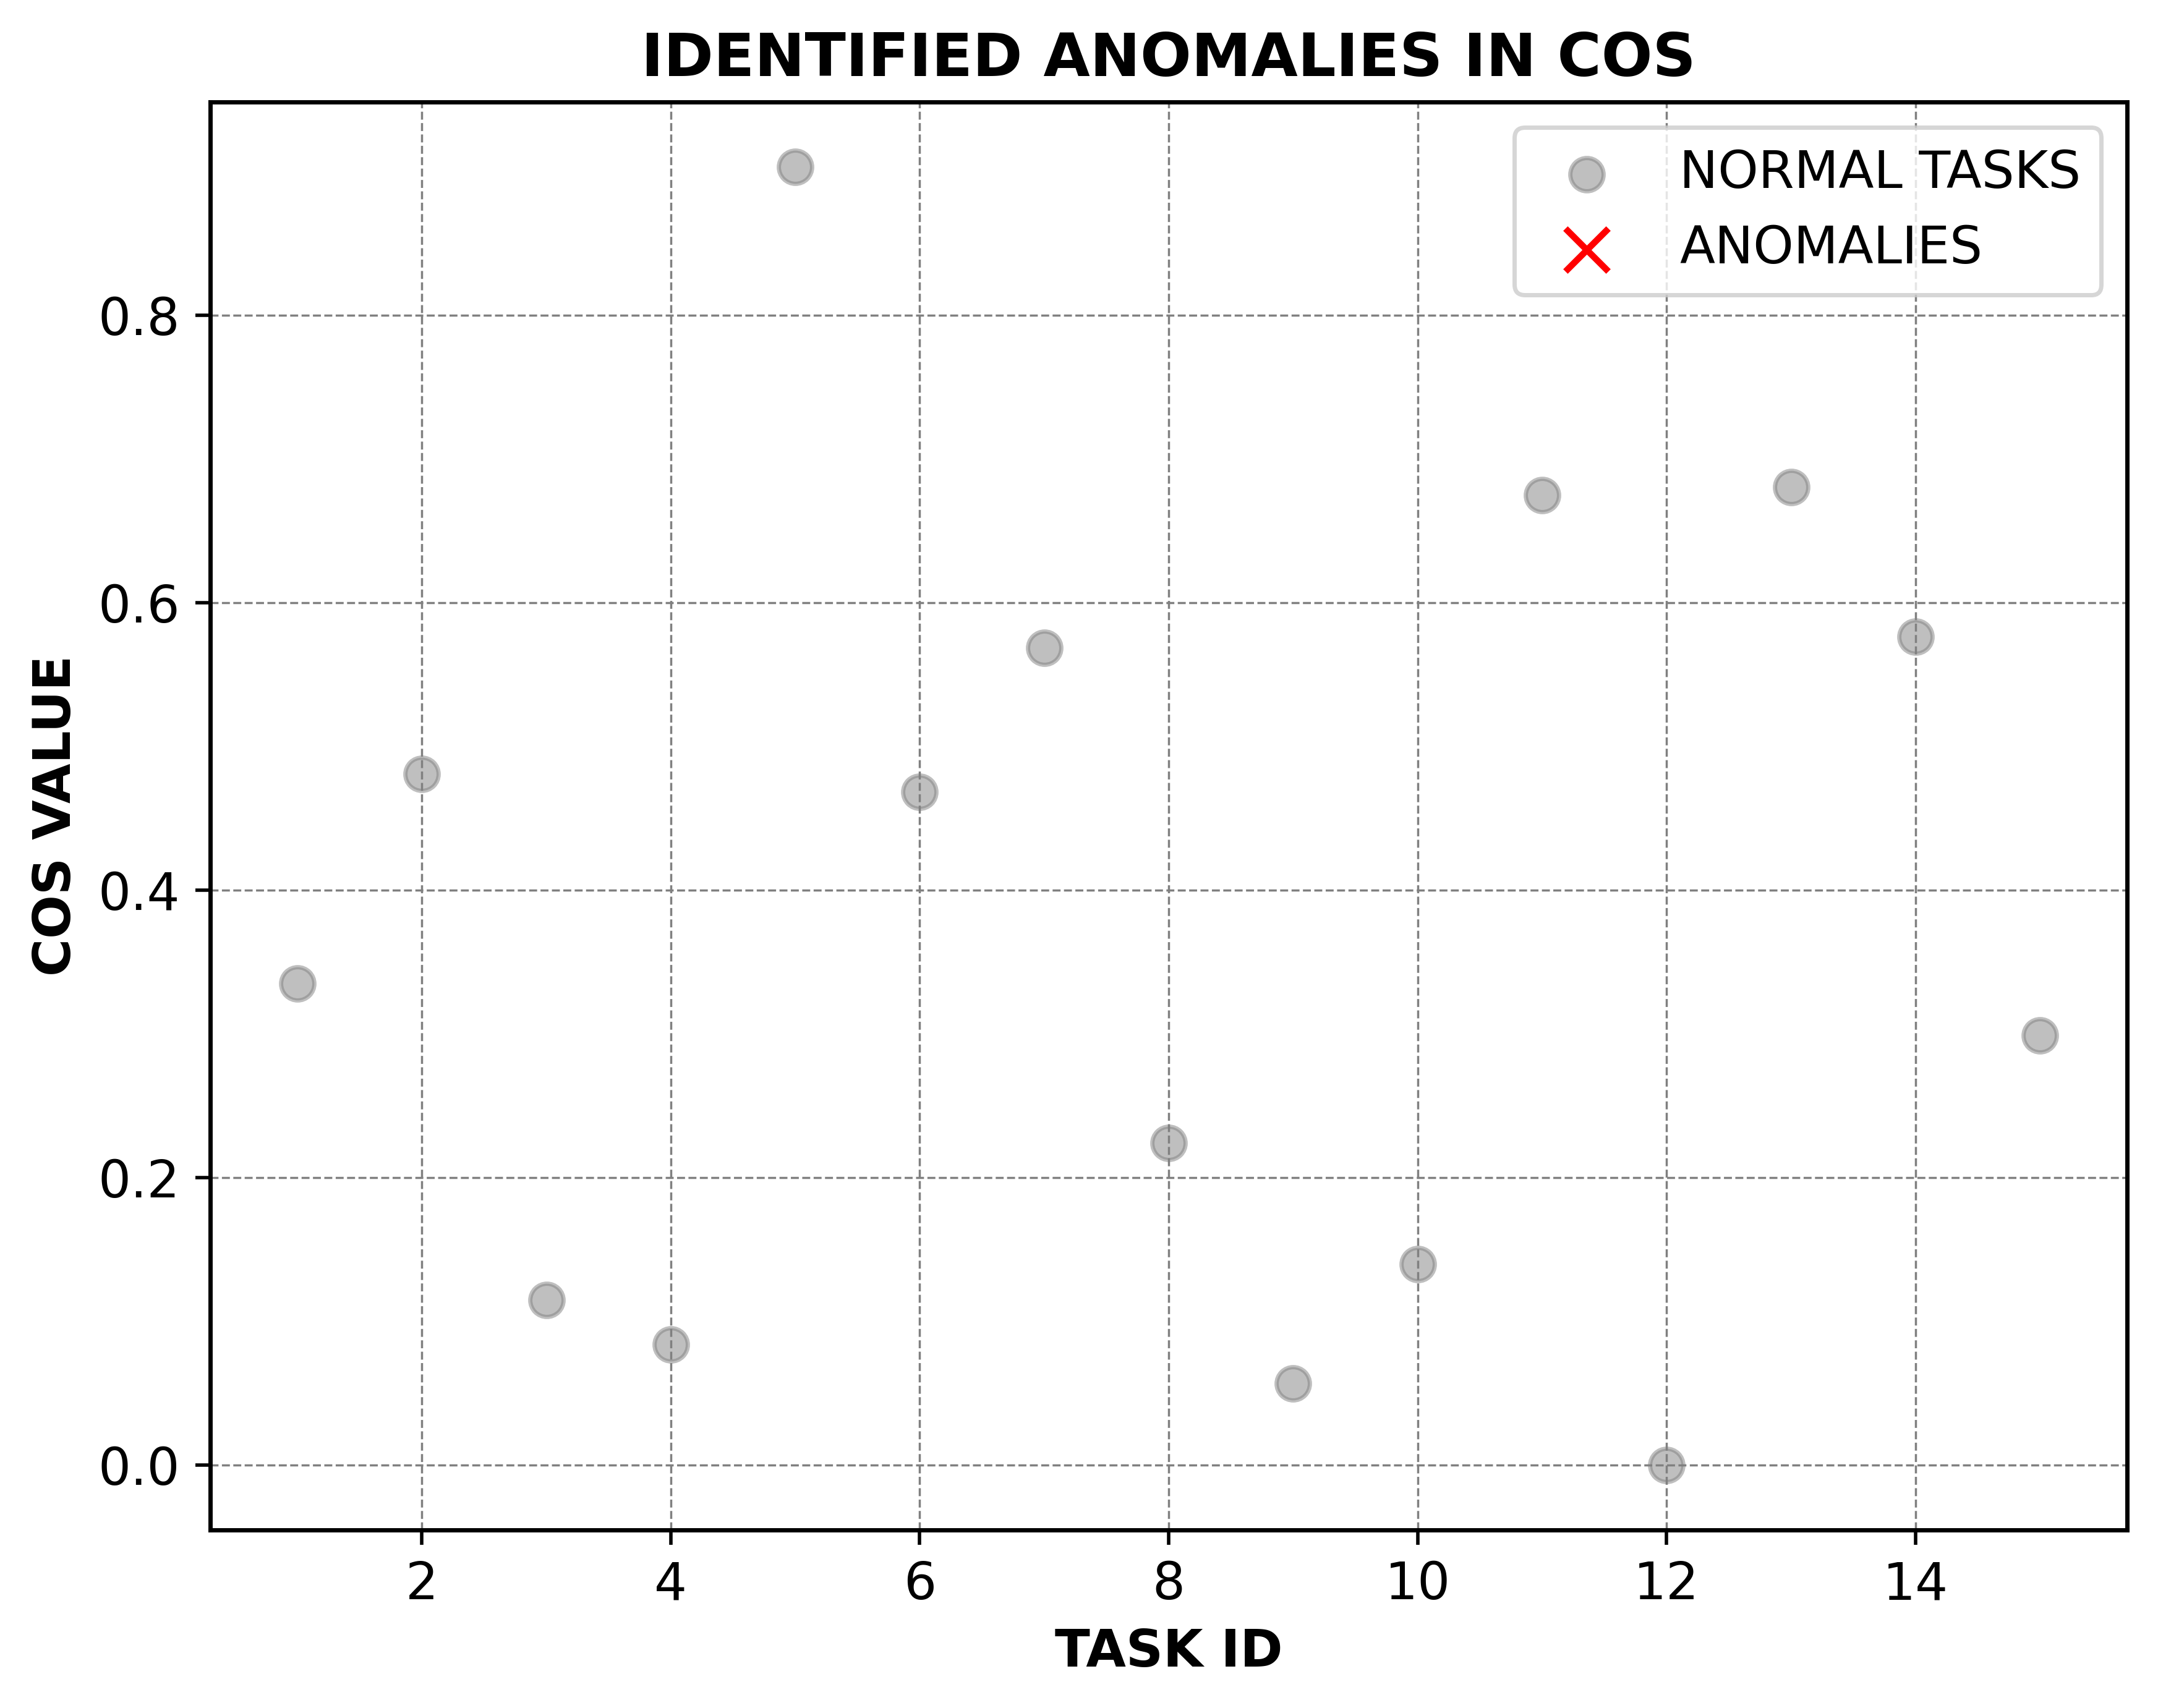

In [25]:
anomalies = df_log[df_log["Is_Anomaly"] == True]

plt.figure(figsize=(8, 6), dpi=500)
plt.scatter(df_log["Task_ID"], df_log["COS"], c="gray", alpha=0.5, label="NORMAL TASKS", s=60)
plt.scatter(anomalies["Task_ID"], anomalies["COS"], c="red", label="ANOMALIES", marker="x", s=100)

plt.xlabel("TASK ID", fontsize=12)
plt.ylabel("COS VALUE", fontsize=12)
plt.title("IDENTIFIED ANOMALIES IN COS", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()